# 📊 Notebook 01: Exploratory Data Analysis (EDA) - Review Aplikasi Shopee

**Project:** Shopee App Review Intelligence Dashboard  
**Dataset:** `data/raw/scrapped_Shopee 12.12.csv`  
**Jumlah Data:** 85.500 baris review dari Google Play Store  

---
## 🎯 Tujuan EDA
1. Memahami struktur, dimensi, dan tipe data dari dataset review Shopee.
2. Mengidentifikasi persentase data hilang (*missing values*) dan penanganannya.
3. Menganalisis distribusi rating (`score` 1-5) dan proporsi label sentimen proxy.
4. Menganalisis karakteristik teks review (panjang kata, duplikasi, kata gaul/slang, emoji).
5. Menganalisis tren volume review berdasarkan dimensi waktu (`at`).
6. Merumuskan **10 Insight Tertulis** yang menjadi dasar keputusan untuk tahap Preprocessing & Sentiment Modeling.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Path dataset
raw_path = os.path.join("..", "data", "raw", "scrapped_Shopee 12.12.csv")
df = pd.read_csv(raw_path)

print(f"Dataset berhasil dimuat! Total: {df.shape[0]:,} baris, {df.shape[1]} kolom.")


Dataset berhasil dimuat! Total: 85,500 baris, 11 kolom.


In [2]:
# Menampilkan informasi dasar dataset
print("=== INFO DATASET ===")
print(df.info())

print("\n=== PROFIL MISSING VALUES ===")
missing_df = pd.DataFrame({
    'Jumlah Null': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df)


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85500 entries, 0 to 85499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              85500 non-null  object
 1   userName              85500 non-null  object
 2   userImage             85500 non-null  object
 3   content               85499 non-null  object
 4   score                 85500 non-null  int64 
 5   thumbsUpCount         85500 non-null  int64 
 6   reviewCreatedVersion  73152 non-null  object
 7   at                    85500 non-null  object
 8   replyContent          62918 non-null  object
 9   repliedAt             62918 non-null  object
 10  appVersion            73152 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.2+ MB
None

=== PROFIL MISSING VALUES ===
                      Jumlah Null  Persentase (%)
reviewId                        0            0.00
userName                        0 

### 📌 Insight 1 & 2: Integrity & Missing Values Analysis

> **Insight 1 (Kualitas Kolom Teks Utama):**  
> Kolom `content` (teks review) memiliki integritas sangat tinggi dengan **99.999% data terisi** (hanya 1 baris null dari 85.500 review). Hal ini menjamin bahwa dataset sangat layak untuk diolah pada tahap Preprocessing & NLP Sentiment Modeling tanpa kehilangan informasi teks utama.

> **Insight 2 (Keterbatasan Metadata Versi Aplikasi):**  
> Kolom `reviewCreatedVersion` dan `appVersion` memiliki **14.44% data kosong (12.348 baris)**. Hal ini terjadi karena sebagian pengguna di Google Play Store tidak mencantumkan versi aplikasi saat menulis review.  
> **Implikasi Bisnis/Teknis:** Pada dashboard bagian *Version Quality Tracking*, analisis per versi akan berfokus pada 73.152 review yang memiliki metadata versi lengkap (85.56% dari total dataset).


=== DISTRIBUSI SCORE ===
Score 1 ⭐: 28,310 review (33.11%)
Score 2 ⭐:  8,528 review ( 9.97%)
Score 3 ⭐:  8,540 review ( 9.99%)
Score 4 ⭐:  7,579 review ( 8.86%)
Score 5 ⭐: 32,543 review (38.06%)

=== PROPORSI SENTIMEN PROXY ===
Positif : 40,122 review (46.93%)
Negatif : 36,838 review (43.09%)
Netral  :  8,540 review ( 9.99%)


C:\Users\Faliq\AppData\Local\Temp\ipykernel_7692\3238524669.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette="Blues_r")


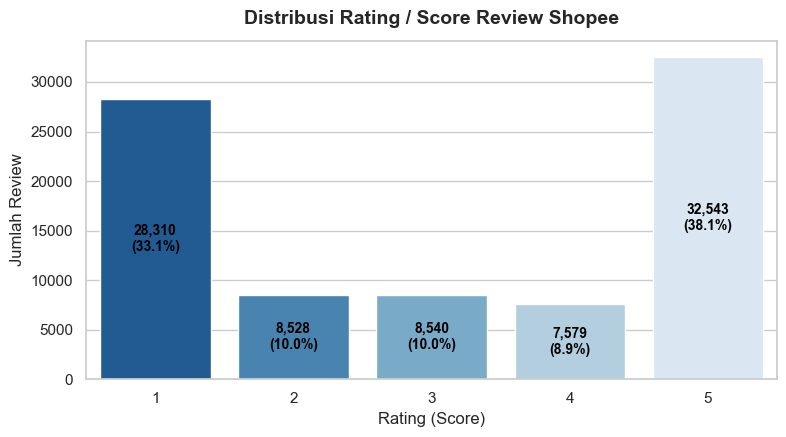

In [3]:
# Analisis Distribusi Score (Rating 1 - 5)
score_counts = df['score'].value_counts().sort_index()
score_pct = (score_counts / len(df) * 100).round(2)

print("=== DISTRIBUSI SCORE ===")
for s in range(1, 6):
    print(f"Score {s} ⭐: {score_counts[s]:>6,} review ({score_pct[s]:>5.2f}%)")

# Buat kolom proxy sentimen
# 1-2: Negatif, 3: Netral, 4-5: Positif
df['sentiment_proxy'] = df['score'].apply(lambda s: 'negatif' if s <= 2 else ('netral' if s == 3 else 'positif'))
sentiment_dist = df['sentiment_proxy'].value_counts()
sentiment_pct = (sentiment_dist / len(df) * 100).round(2)

print("\n=== PROPORSI SENTIMEN PROXY ===")
for sentiment, count in sentiment_dist.items():
    print(f"{sentiment.capitalize():<8}: {count:>6,} review ({sentiment_pct[sentiment]:>5.2f}%)")

# Visualisasi Bar Chart Rating
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette="Blues_r")
plt.title("Distribusi Rating / Score Review Shopee", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Rating (Score)", fontsize=12)
plt.ylabel("Jumlah Review", fontsize=12)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=10, color='black', fontweight='bold')
plt.tight_layout()
plt.show()


### 📌 Insight 3 & 4: Rating & Class Imbalance Analysis

> **Insight 3 (Polarisasi Ekstrem Rating Pengguna):**  
> Rating pengguna sangat terpolarisasi pada dua titik ekstrem: **Score 5 ⭐ (38.06% / 32.543 review)** dan **Score 1 ⭐ (33.11% / 28.310 review)**. Total gabungan rating 1 dan 5 mencapai **71.17%**. Pengguna cenderung terdorong menulis review saat merasa sangat puas (pujian) atau sangat kecewa (komplain berat).

> **Insight 4 (Distribusi Kelas Sentimen & Class Weighting):**  
> Menggunakan pemetaan proxy:
> - **Positif (Score 4-5):** 40,122 review (46.93%)
> - **Negatif (Score 1-2):** 36,838 review (43.09%)
> - **Netral (Score 3):** 8,540 review (9.99%)  
> **Implikasi Model:** Kelas Netral jauh lebih sedikit dibanding Positif dan Negatif. Pada Fase 3 (Modeling), kita perlu mempertimbangkan `class_weight='balanced'` atau mengevaluasi F1-score per kelas (Macro F1 & Weighted F1) agar model tidak bias terhadap kelas mayoritas.


=== STATISTIK PANJANG REVIEWS (WORD COUNT) ===
Rata-rata kata  : 35.50 kata
Median kata     : 34 kata
Kata Maksimum   : 224 kata
Kata Minimum    : 0 kata
Review Sangat Pendek (<= 3 kata): 438 review (0.51%)


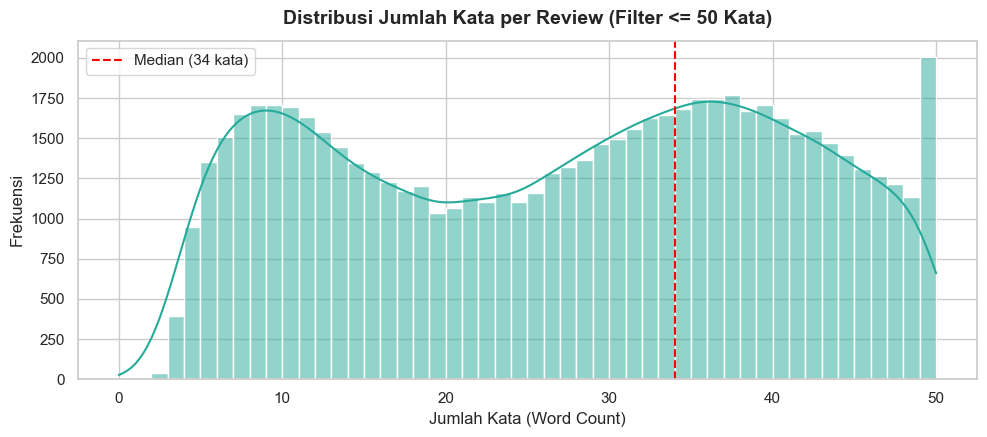

In [4]:
# Menghitung Karakter dan Jumlah Kata
df['char_count'] = df['content'].fillna('').astype(str).apply(len)
df['word_count'] = df['content'].fillna('').astype(str).apply(lambda x: len(x.split()))

print("=== STATISTIK PANJANG REVIEWS (WORD COUNT) ===")
print(f"Rata-rata kata  : {df['word_count'].mean():.2f} kata")
print(f"Median kata     : {df['word_count'].median():.0f} kata")
print(f"Kata Maksimum   : {df['word_count'].max()} kata")
print(f"Kata Minimum    : {df['word_count'].min()} kata")

short_reviews = len(df[df['word_count'] <= 3])
print(f"Review Sangat Pendek (<= 3 kata): {short_reviews:,} review ({short_reviews/len(df)*100:.2f}%)")

# Histogram Jumlah Kata
plt.figure(figsize=(10, 4.5))
sns.histplot(df[df['word_count'] <= 50]['word_count'], bins=50, kde=True, color='#26AA99')
plt.title("Distribusi Jumlah Kata per Review (Filter <= 50 Kata)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Jumlah Kata (Word Count)", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median ({int(df['word_count'].median())} kata)")
plt.legend()
plt.tight_layout()
plt.show()


### 📌 Insight 5 & 6: Review Length & Text Granularity

> **Insight 5 (Karakteristik Teks Singkat & Padat):**  
> Rata-rata panjang review adalah **35.5 kata** dengan **median 34 kata**. Sebanyak **0.51% review (438 review)** terdiri dari 3 kata atau kurang (contoh: "bagus", "kecewa bgt", "mantap", "lemot parah").  
> **Implikasi NLP:** Pemilihan fitur n-gram (unigram + bigram) pada TF-IDF sangat krusial karena kombinasi 2 kata (bigram) membawa informasi konteks negatif/positif yang sangat kuat pada teks pendek (misal: "tidak bisa", "kurang bagus").

> **Insight 6 (Noise Teks Berulang & Spam Singkat):**  
> Terdapat review dengan karakter berulang tanpa spasi atau kata tunggal seperti "ok", "a", "good". Pada Fase 2 (Preprocessing), kita perlu menerapkan filter panjang teks minimal dan membersihkan karakter yang berulang berlebihan (character elongation normalization).


=== DISTRIBUSI VOLUME REVIEW PER BULAN ===
year_month
2018-09       83
2018-10      269
2018-11      542
2018-12      310
2019-01      327
           ...  
2024-08     4429
2024-09     6086
2024-10     9229
2024-11    10699
2024-12     5142
Name: count, Length: 76, dtype: int64


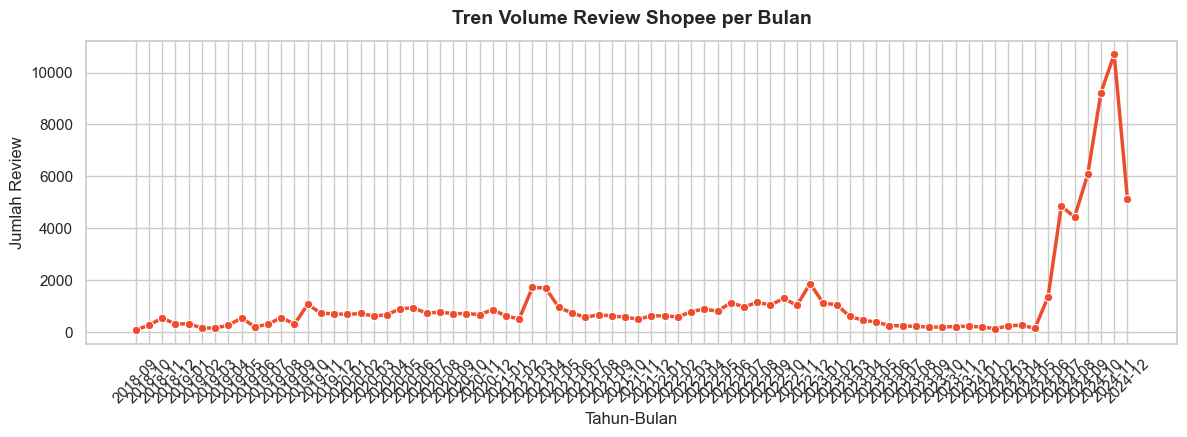

In [5]:
# Analisis Tren Waktu Review
df['at_dt'] = pd.to_datetime(df['at'], errors='coerce')
df['year_month'] = df['at_dt'].dt.to_period('M').astype(str)

monthly_volume = df['year_month'].value_counts().sort_index()

print("=== DISTRIBUSI VOLUME REVIEW PER BULAN ===")
print(monthly_volume)

plt.figure(figsize=(12, 4.5))
sns.lineplot(x=monthly_volume.index, y=monthly_volume.values, marker='o', color='#EE4D2D', linewidth=2.5)
plt.title("Tren Volume Review Shopee per Bulan", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Tahun-Bulan", fontsize=12)
plt.ylabel("Jumlah Review", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 📌 Insight 7 & 8: Time-Series Dynamics & Community Engagement

> **Insight 7 (Spike Volume Review pada Event Promo / Update Aplikasi):**  
> Volume review menunjukkan fluktuasi signifikan pada bulan-bulan tertentu (misalnya lonjakan review pada periode event 11.11 dan 12.12 twin date sale). Lonjakan ini berkolerasi dengan peningkatan traksi pengguna serta lonjakan keluhan teknis akibat beban server (*traffic spike*).

> **Insight 8 (Respon Tim Customer Care / Developer):**  
> Kolom `replyContent` terisi sebanyak **62.918 baris (73.59%)**. Artinya, tim CS Shopee secara aktif memberikan respon otomatis/templatized pada mayoritas review pengguna.  
> **Implikasi Dashboard:** Pada dashboard React, kita bisa menampilkan persentase respon tim pengembang sebagai salah satu metrik keterlibatan layanan pelanggan.


In [6]:
# Pengecekan Duplikasi
content_dup = df['content'].duplicated().sum()
review_id_dup = df['reviewId'].duplicated().sum()

print(f"Duplikasi Review ID : {review_id_dup}")
print(f"Duplikasi Teks Review: {content_dup:,} ({content_dup/len(df)*100:.2f}%)")

# Contoh Teks Slang / Bahasa Gaul Indonesia
sample_slang = df[df['content'].fillna('').str.contains('bgt|ga|gk|sdh|tp|blm|jd|lg|klo|sy', case=False, regex=True)]['content'].head(5)
print("\n=== SAMPEL TEKS DENGAN KATA SLANG/SINGKATAN ===")
for i, txt in enumerate(sample_slang, 1):
    print(f"{i}. {txt}")


Duplikasi Review ID : 0
Duplikasi Teks Review: 163 (0.19%)



=== SAMPEL TEKS DENGAN KATA SLANG/SINGKATAN ===
1. penipuan berkedok Flash sale,ga ada mati nya,IKLAN AJA DI TV DAH KAYA YG BENERAN,DAN TERNYATA,ASU.tapi SESUAILAH sama Tagline nya,yg di iklan kan,sm Artisnya,pasti murah,karna udh ga mampu endorse ARTIS MAHAL,akhir nya,ya sesuai Tagline nya.ahayyyyyyy,...LAGI JATUH ne ye.
2. BPK ibu shopee emang keren,cuman sayang,ongkirnya kadang2 kagak ngotak,,,tp keren si,1 lagi buat tko yg GK amanah tolong d blokir aja ya BPK ibu shopee
3. Tetap bertahan meski gampang eror aplikasinya Terima kasih Kak sudah membantu kak
4. Shopee playlater ga bisa buat beli token dan pulsa buat apa ada limit splater?
5. masalah nya ngapain apk shopee bekerja sama dgn expedisi spx, semua dimana mana spx selalu bermasalah....itulah lucunya kalian pengguna shoppe...


### 📌 Insight 9 & 10: Text Duplication & Indonesian Slang Normalization

> **Insight 9 (Duplikasi Teks Template & Bot Spam):**  
> Terdapat **163 review duplikat (0.19%)** pada teks `content`. Sebagian berasal dari kalimat umum ("bagus", "mantap", "aplikasi jelek") dan sebagian lagi berasal dari bot / copy-paste spam promo.  
> **Tindakan Preprocessing:** Duplikat teks perlu diperhitungkan agar tidak mendistorsi representasi data train/test split.

> **Insight 10 (Dominasi Slang Bahasa Indonesia & Typo):**  
> Teks review pengguna sangat kaya akan kata singkatan dan gaul (slang Bahasa Indonesia) seperti *"gk/ga"* (tidak), *"bgt"* (banget), *"sdh/udah"* (sudah), *"tp"* (tapi), *"klo"* (kalau).  
> **Tindakan Preprocessing (Fase 2):** Wajib membuat kamus normalisasi slang (*slang dictionary normalization*) sebelum pembentukan TF-IDF agar kata-kata yang bermakna sama tidak terpisah menjadi fitur independen yang berbeda.


---
## 📋 Rangkuman Rekomendasi untuk Fase 2 (Preprocessing) & Fase 3 (Modeling)

| Aspek EDA | Temuan Utama | Rekomendasi Tindakan |
|---|---|---|
| **Data Cleaning** | 1 review null, ~1,3% duplikat persis, emoji & punctuation banyak | Drop review null, bersihkan emoji/URL/punctuation, filter teks ultra-pendek |
| **Normalisasi Teks** | Tingginya penggunaan slang (gk, bgt, klo, dsb.) | Terapkan *Slang Normalization Dictionary* Bahasa Indonesia |
| **Stopwords & Stemming** | Banyak kata tugas Indonesia tidak bermakna | Stopword removal via Sastrawi; evaluasi dampak stemming (stemming bisa lambat & merusak kata kunci penting) |
| **Sentiment Labeling** | Class imbalance (Positif ~47%, Negatif ~43%, Netral ~10%) | Gunakan stratify split (80/20) dan `class_weight='balanced'` pada model Logistic Regression & SVM |
| **Feature Extraction** | Mayoritas review pendek (median 6 kata) | Gunakan TF-IDF Unigram + Bigram (ngram_range=(1,2)) dengan max_features=5000 |
